In [1]:
# General Imports
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Scripts 
folder_path = os.path.abspath("scripts")
sys.path.append(folder_path)

# Derivation of Column Density Maps Routine
from Derive_Density_Maps import derive_density_maps, convert_to_mass

# Visualization Tools
from visualization_tools import show_regions_with_sections, show_Minkowski_Functionals, show_sections_OrionB_vertical, visualize_Mass_Size_D_Diagrams, visualize_Mass_Size_D_Diagramm_as_One

# Minkowski Functionals
from Minkowski_Fractal_Dimension import standard_minkowski_functionals, horizontal_marching_minkowski_functionals, vertical_marching_minkowski_functionals, intercept_corrected_minkowski_functionals 

# Box Counting 
from Box_Counting_Fractal_Dimension import box_counting

# Dendogram-like Tracker
from region_tracker import track_largest_regions, save_regions_to_pickle, load_regions_from_pickle, get_region_from_fractal_dimension_mass_and_size

# Derive Density Maps
N_H2, N_H2_OA, N_H2_OB, wcs, wcs_OA, wcs_OB = derive_density_maps()

[08:54:39] ERROR    PARDISO solver not installed, run `pip install pypardiso`. Otherwise,          ]8;id=359208;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py\_workspace.py]8;;\:]8;id=37437;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py#56\56]8;;\
                    simulations will be slow. Apple M chips not supported.                                         

<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
C:\Users\User\AppData\Local\Temp\ipykernel_10020\2170041180.py:29: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Column Density Threshold [$\mathrm{cm}^{-2}$]', fontsize=18)


2.9378819243906555
2.860226447812054


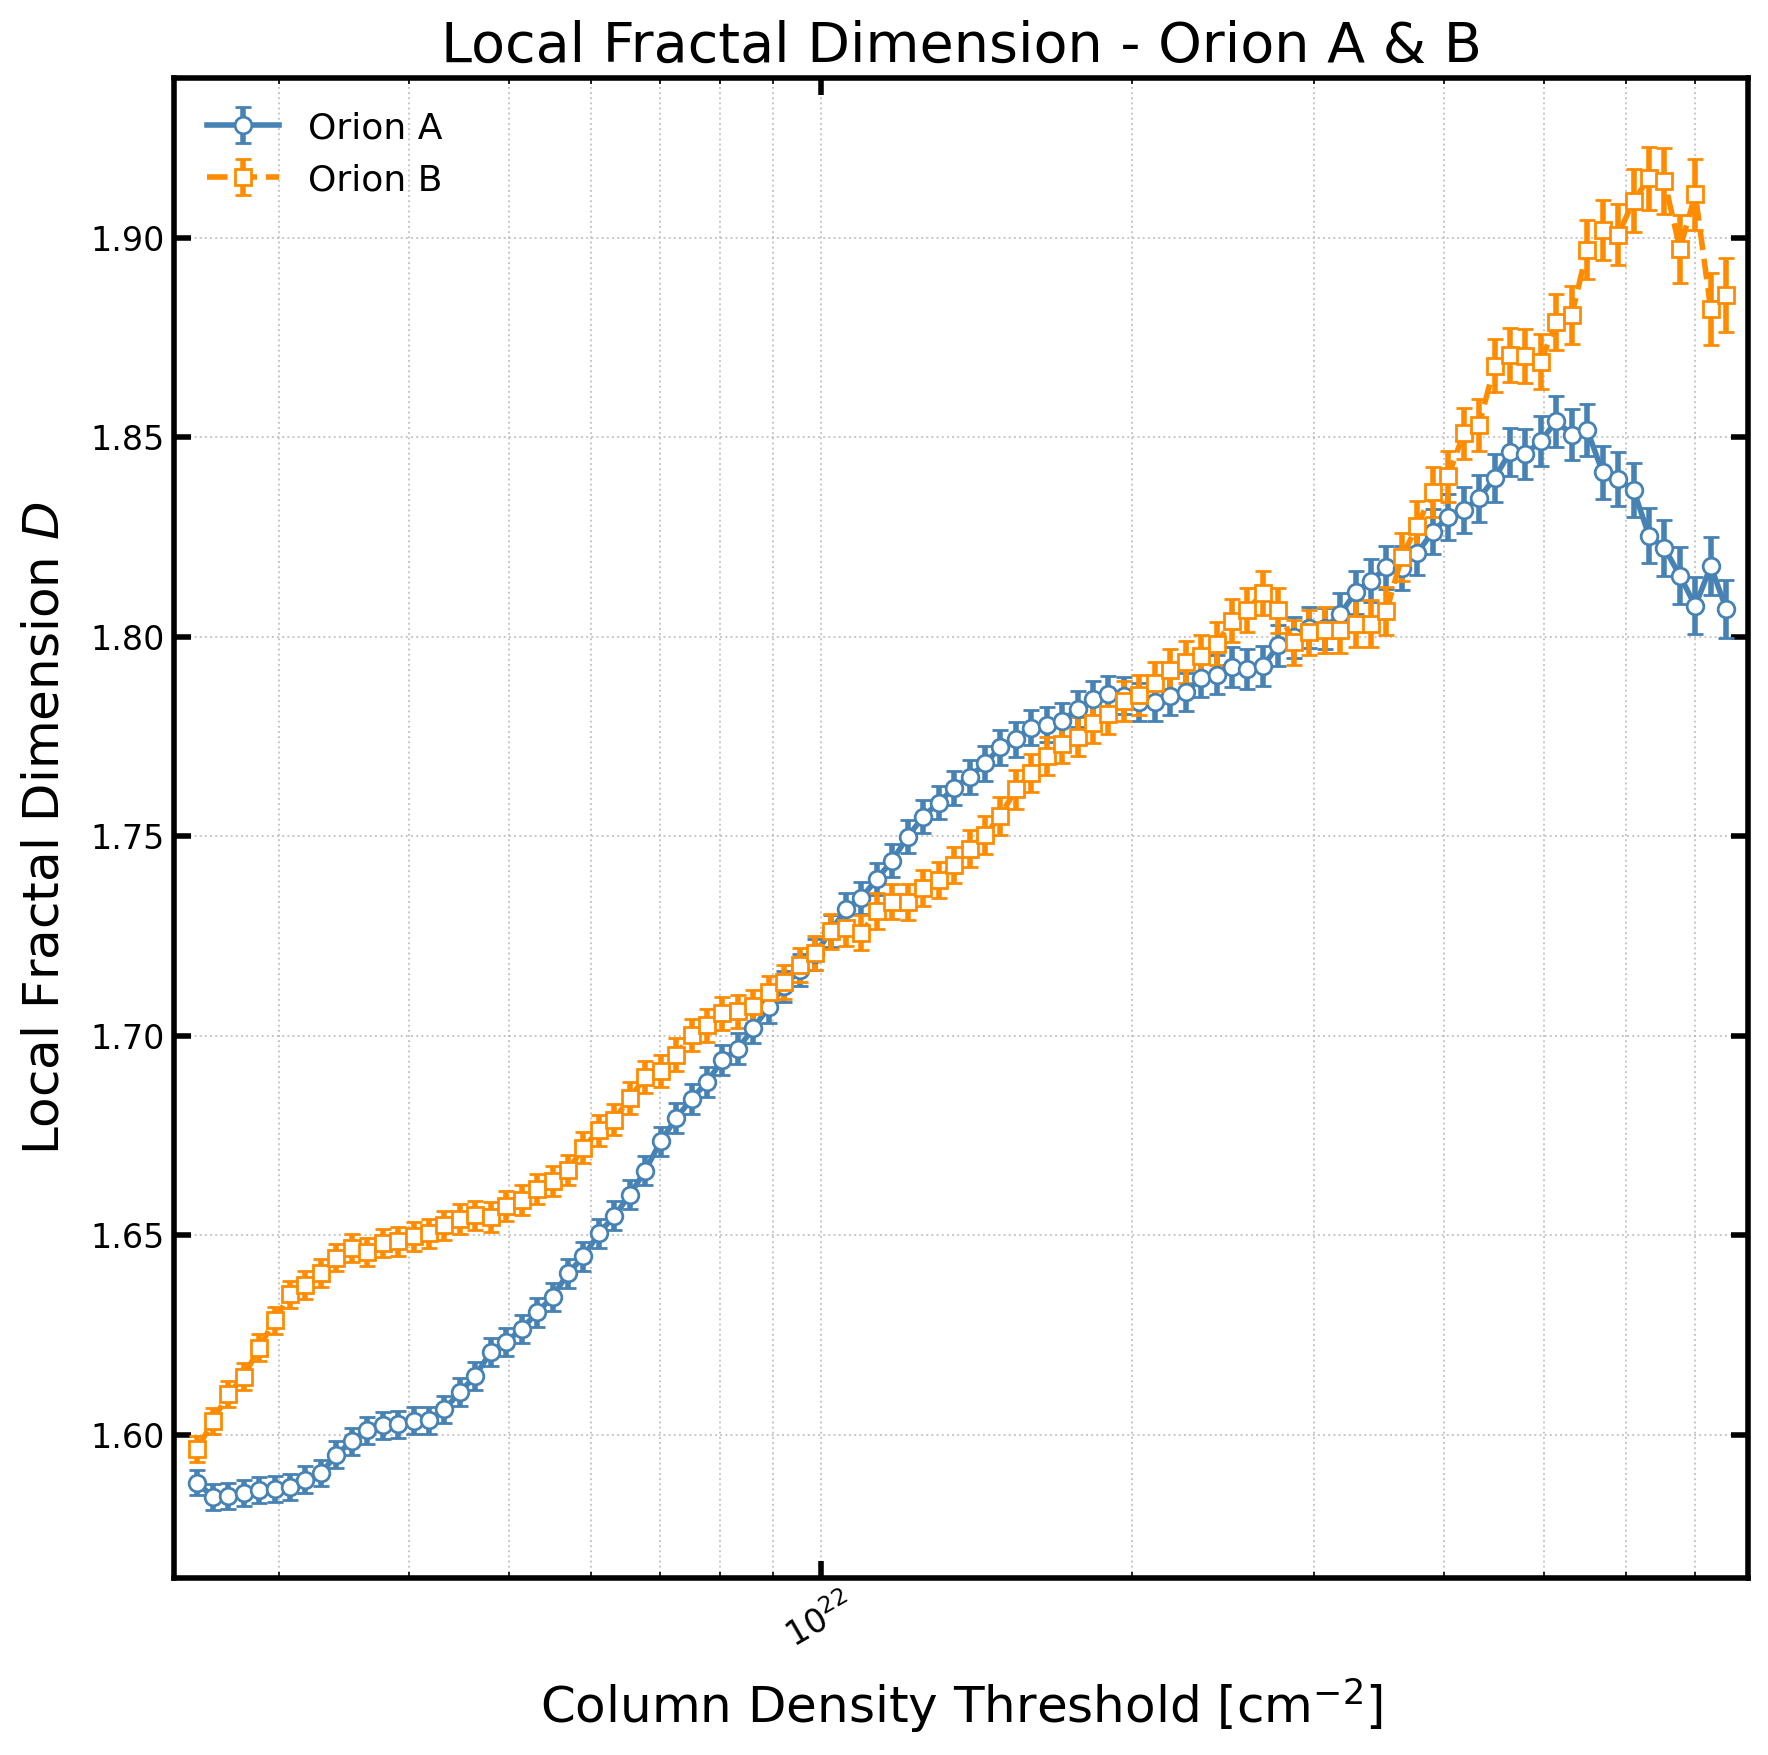

In [3]:
# Fractal Dimension as a function of N

# Orion A
region_name = "Orion A"

# overall, these work best for the whole region
threshold_min = 2.5e21
threshold_max = 7.5e22 # This works well when the fractal dimension is calculated for the whole region, but for the individual regions it might be good to go further down
# threshold_max = 1.0e23

# Minkowski
results_OA = standard_minkowski_functionals(N_H2_OA, threshold_min = threshold_min, threshold_max = threshold_max)

results_OB = standard_minkowski_functionals(N_H2_OB, threshold_min = threshold_min, threshold_max = threshold_max)

plt.figure(figsize=(9, 9))

# Plot with error bars
plt.errorbar(results_OA["thresholds"], results_OA["fractal_dimension"], 
             yerr=results_OA["sigma_D"], fmt='o-', 
             label="Orion A", color='steelblue', markersize=6, capsize=3)

plt.errorbar(results_OB["thresholds"], results_OB["fractal_dimension"], 
             yerr=results_OB["sigma_D"], fmt='s--', 
             label="Orion B", color='darkorange', markersize=6, capsize=3)

# Title and labels
plt.title("Local Fractal Dimension - Orion A & B", fontsize=20)
plt.xlabel('Column Density Threshold [$\mathrm{cm}^{-2}$]', fontsize=18)
plt.ylabel('Local Fractal Dimension $D$', fontsize=18)

# Log scale and grid
plt.xscale("log")
plt.grid(True, which='both', linestyle=':', linewidth=0.7, alpha=0.7)

# Tick adjustments
plt.tick_params(axis='both', which='major', labelsize=12)
plt.xticks(rotation=30)
plt.xlim([threshold_min - threshold_min/20, threshold_max+threshold_max/20])

# Legend
plt.legend(frameon=False, fontsize=13)

# Tight layout for slides
plt.tight_layout()

In [ ]:
import scipy.ndimage as ndimage
from skimage.measure import perimeter
import numpy as np

import pickle

def pca_major_axis(region_coords):
    """
    Computes the major axis length of a structure using PCA.
    The major axis is the square root of the largest eigenvalue of the covariance matrix.
    """
    if len(region_coords) < 2:
        return 0  # If only one pixel, size is zero

    # Center the coordinates
    centered_coords = region_coords - np.mean(region_coords, axis=0)

    # Compute covariance matrix and its eigenvalues
    cov_matrix = np.cov(centered_coords, rowvar=False)
    eigenvalues, _ = np.linalg.eigh(cov_matrix)

    # The largest eigenvalue corresponds to the major axis squared
    major_axis = 2 * np.sqrt(np.max(eigenvalues))  # Factor 2 to approximate full length

    return major_axis

def calculate_mass_and_size(region_mask, M_H2, pc_per_px):
    """
    Calculate the mass and the major axis of a structure using PCA.
    - Mass: Summed pixel values converted to solar masses.
    - Size: Major axis computed from PCA eigenvalues.
    """
    # Compute total mass
    mass = np.sum(M_H2[region_mask])

    # Find structure coordinates
    region_coords = np.column_stack(np.where(region_mask))

    if len(region_coords) == 0:
        return mass, 0  # If no region is found, return zero size

    # Compute the major axis length using PCA
    major_axis_length = pca_major_axis(region_coords)

    # Convert size to parsecs
    size_parsecs = major_axis_length * pc_per_px

    return mass, size_parsecs

def compute_fractal_dimension(region_mask):
    """
    Compute the fractal dimension of a binary region using the Perimeter-Area relation.
    
    Parameters:
        region_mask (ndarray): Boolean mask of the structure.
        
    Returns:
        float: Estimated fractal dimension.
    """
    area = np.sum(region_mask)
    
    # Compute perimeter using dilation technique
    mask_perimeter = perimeter(region_mask)

    if area > 0 and mask_perimeter > 0:
        return 2*(np.log10(mask_perimeter) / np.log10(area))
    return None  # Invalid case (avoid division errors)

def track_largest_regions_NEW(N_H2, M_H2, thresholds, pc_per_px, num_top_regions=None, min_region_size_px=50):
    """
    Extract regions at each threshold and compute their properties.
    """
    regions = {}

    for threshold in thresholds:
        mask = N_H2 >= threshold  
        labeled_regions, num_features = ndimage.label(mask)

        if num_features == 0:
            print(f"[{threshold}] No regions found.")
            continue

        region_sizes = {
            region_id: np.sum(labeled_regions == region_id)
            for region_id in range(1, num_features + 1)
        }

        # Filter by size or pick top N
        region_ids = sorted(region_sizes, key=region_sizes.get, reverse=True)
        if num_top_regions is not None:
            region_ids = region_ids[:num_top_regions]

        saved_count = 0
        for region_id in region_ids:
            size_px = region_sizes[region_id]
            if size_px < min_region_size_px:
                continue

            region_mask = labeled_regions == region_id
            fractal_dim = compute_fractal_dimension(region_mask)
            mass, size = calculate_mass_and_size(region_mask, M_H2, pc_per_px)

            region_key = f"{threshold}_{region_id}"
            regions[region_key] = {
                "threshold": threshold,
                "fractal_dimension": fractal_dim,
                "mass": mass,
                "size": size,
                "region_mask": region_mask
            }
            saved_count += 1

        print(f"[{threshold}] Found {num_features} regions, saved {saved_count}.")

    return regions

In [ ]:
# Dendograms-like approach to retrieve regions
pixel_scale = 0.00417
distance = 412 
radians = 180/np.pi #conversion factor: rad in deg
rad_per_px = pixel_scale/radians
pc_per_px = np.sin(rad_per_px)*distance

M_H2_OA = convert_to_mass(N_H2_OA)

thresholds = np.logspace(np.log10(2.5e21), np.log10(8.5e22), 100) 

if os.path.exists("top_regions_data_OA.pkl"):
    top_regions_data_OA = load_regions_from_pickle("top_regions_data_OA.pkl")
else:
    top_regions_data_OA = track_largest_regions_NEW(N_H2_OA, M_H2_OA, thresholds, pc_per_px, num_top_regions=20, min_region_size_px=15)
    # save_regions_to_pickle(top_regions_data_OA, "top_regions_data_OA.pkl")

# Plot fractal dimensions for each threshold
thresholds = np.unique([region_data["threshold"] for region_data in top_regions_data_OA.values()])

plt.figure(figsize=(14, 8))

average_fractal_dimensions = []

for i, threshold in enumerate(thresholds):
    fractal_dimensions = [
        region_data["fractal_dimension"]
        for region_data in top_regions_data_OA.values()
        if region_data["threshold"] == threshold
    ]
    plt.scatter(
        [threshold] * len(fractal_dimensions),
        fractal_dimensions,
        color="black"
    )
    if fractal_dimensions:
        average_fractal_dimensions.append(np.mean(fractal_dimensions))
    else:
        average_fractal_dimensions.append(np.nan)

plt.scatter(thresholds, average_fractal_dimensions, color='red', label="Average Fractal Dimension")

thresholds_full = np.logspace(np.log10(2.5e21), np.log10(8.5e22), 100)
plt.scatter(thresholds_full, results_OA["fractal_dimension"], label="Whole Region")

plt.xscale("log")
plt.xlabel("Threshold")
plt.ylabel("Fractal Dimension")
plt.title("Fractal Dimension vs. Threshold for Top Regions in Orion A", fontweight='bold')
plt.legend()
plt.show()

In [ ]:
# Dendograms-like approach to retrieve regions

pixel_scale = 0.00417
distance = 412 
radians = 180/np.pi #conversion factor: rad in deg
rad_per_px = pixel_scale/radians
pc_per_px = np.sin(rad_per_px)*distance

M_H2_OB = convert_to_mass(N_H2_OB)

thresholds = np.logspace(np.log10(2.5e21), np.log10(8.5e22), 100) 

if os.path.exists("top_regions_data_OB.pkl"):
    top_regions_data_OB = load_regions_from_pickle("top_regions_data_OB.pkl")
else:
    top_regions_data_OB = track_largest_regions_NEW(N_H2_OB, M_H2_OB, thresholds, pc_per_px, num_top_regions=20, min_region_size_px=15)
    # save_regions_to_pickle(top_regions_data_OA, "top_regions_data_OA.pkl")

# Plot fractal dimensions for each threshold
thresholds = np.unique([region_data["threshold"] for region_data in top_regions_data_OB.values()])

plt.figure(figsize=(14, 8))

average_fractal_dimensions = []

for i, threshold in enumerate(thresholds):
    fractal_dimensions = [
        region_data["fractal_dimension"]
        for region_data in top_regions_data_OB.values()
        if region_data["threshold"] == threshold
    ]
    plt.scatter(
        [threshold] * len(fractal_dimensions),
        fractal_dimensions,
        color="black"
    )
    if fractal_dimensions:
        average_fractal_dimensions.append(np.mean(fractal_dimensions))
    else:
        average_fractal_dimensions.append(np.nan)

plt.scatter(thresholds, average_fractal_dimensions, color='red', label="Average Fractal Dimension")

thresholds_full = np.logspace(np.log10(2.5e21), np.log10(8.5e22), 100)
plt.scatter(thresholds_full, results_OB["fractal_dimension"], label="Whole Region")

plt.xscale("log")
plt.xlabel("Threshold")
plt.ylabel("Fractal Dimension")
plt.title("Fractal Dimension vs. Threshold for Top Regions in Orion B", fontweight='bold')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from scipy.ndimage import center_of_mass

# Create the visualization mask
first_threshold = thresholds_full[0]
region_keys_first_threshold = [
    key for key, data in top_regions_data_OA.items()
    if np.isclose(data["threshold"], first_threshold)
]

example_mask = next(iter(top_regions_data_OA.values()))["region_mask"]
all_regions_mask = np.zeros_like(example_mask, dtype=int)

for idx, key in enumerate(region_keys_first_threshold, 1):
    all_regions_mask[top_regions_data_OA[key]["region_mask"]] = idx

plt.figure(figsize=(10, 10))
plt.imshow(all_regions_mask, cmap='tab20', origin='lower')

for idx, key in enumerate(region_keys_first_threshold, 1):
    mask = top_regions_data_OA[key]["region_mask"]
    if not np.any(mask):
        continue

    # Smarter placement: use center of mass instead of mean
    y, x = center_of_mass(mask)
    y = y - 10

    # Get fractal dimension
    fd = top_regions_data_OA[key]["fractal_dimension"]

    # Format the text with a white outline (halo effect)
    txt = plt.text(x, y, f"{fd:.2f}",
                   color='black', fontsize=8, ha='center', va='center', fontweight='bold')
    txt.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])

plt.title(f"Biggest Structures at Threshold {first_threshold:.2e}")
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# Create the visualization mask
first_threshold = thresholds_full[30]
region_keys_first_threshold = [
    key for key, data in top_regions_data_OA.items()
    if np.isclose(data["threshold"], first_threshold)
]

example_mask = next(iter(top_regions_data_OA.values()))["region_mask"]
all_regions_mask = np.zeros_like(example_mask, dtype=int)

for idx, key in enumerate(region_keys_first_threshold, 1):
    all_regions_mask[top_regions_data_OA[key]["region_mask"]] = idx

plt.figure(figsize=(10, 10))
plt.imshow(all_regions_mask, cmap='tab20', origin='lower')

for idx, key in enumerate(region_keys_first_threshold, 1):
    mask = top_regions_data_OA[key]["region_mask"]
    if not np.any(mask):
        continue

    # Smarter placement: use center of mass instead of mean
    y, x = center_of_mass(mask)
    y = y - 10

    # Get fractal dimension
    fd = top_regions_data_OA[key]["fractal_dimension"]

    # Format the text with a white outline (halo effect)
    txt = plt.text(x, y, f"{fd:.2f}",
                   color='black', fontsize=8, ha='center', va='center', fontweight='bold')
    txt.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])

plt.title(f"Biggest Structures at Threshold {first_threshold:.2e}")
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# Create the visualization mask
first_threshold = thresholds_full[40]
region_keys_first_threshold = [
    key for key, data in top_regions_data_OA.items()
    if np.isclose(data["threshold"], first_threshold)
]

example_mask = next(iter(top_regions_data_OA.values()))["region_mask"]
all_regions_mask = np.zeros_like(example_mask, dtype=int)

for idx, key in enumerate(region_keys_first_threshold, 1):
    all_regions_mask[top_regions_data_OA[key]["region_mask"]] = idx

plt.figure(figsize=(10, 10))
plt.imshow(all_regions_mask, cmap='tab20', origin='lower')

for idx, key in enumerate(region_keys_first_threshold, 1):
    mask = top_regions_data_OA[key]["region_mask"]
    if not np.any(mask):
        continue

    # Smarter placement: use center of mass instead of mean
    y, x = center_of_mass(mask)
    y = y - 10

    # Get fractal dimension
    fd = top_regions_data_OA[key]["fractal_dimension"]

    # Format the text with a white outline (halo effect)
    txt = plt.text(x, y, f"{fd:.2f}",
                   color='black', fontsize=8, ha='center', va='center', fontweight='bold')
    txt.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])

plt.title(f"Biggest Structures at Threshold {first_threshold:.2e}")
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# Create the visualization mask
first_threshold = thresholds_full[50]
region_keys_first_threshold = [
    key for key, data in top_regions_data_OA.items()
    if np.isclose(data["threshold"], first_threshold)
]

example_mask = next(iter(top_regions_data_OA.values()))["region_mask"]
all_regions_mask = np.zeros_like(example_mask, dtype=int)

for idx, key in enumerate(region_keys_first_threshold, 1):
    all_regions_mask[top_regions_data_OA[key]["region_mask"]] = idx

plt.figure(figsize=(10, 10))
plt.imshow(all_regions_mask, cmap='tab20', origin='lower')

for idx, key in enumerate(region_keys_first_threshold, 1):
    mask = top_regions_data_OA[key]["region_mask"]
    if not np.any(mask):
        continue

    # Smarter placement: use center of mass instead of mean
    y, x = center_of_mass(mask)
    y = y - 10

    # Get fractal dimension
    fd = top_regions_data_OA[key]["fractal_dimension"]

    # Format the text with a white outline (halo effect)
    txt = plt.text(x, y, f"{fd:.2f}",
                   color='black', fontsize=8, ha='center', va='center', fontweight='bold')
    txt.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])

plt.title(f"Biggest Structures at Threshold {first_threshold:.2e}")
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# Create the visualization mask
first_threshold = thresholds_full[80]
region_keys_first_threshold = [
    key for key, data in top_regions_data_OA.items()
    if np.isclose(data["threshold"], first_threshold)
]

example_mask = next(iter(top_regions_data_OA.values()))["region_mask"]
all_regions_mask = np.zeros_like(example_mask, dtype=int)

for idx, key in enumerate(region_keys_first_threshold, 1):
    all_regions_mask[top_regions_data_OA[key]["region_mask"]] = idx

plt.figure(figsize=(10, 10))
plt.imshow(all_regions_mask, cmap='tab20', origin='lower')

for idx, key in enumerate(region_keys_first_threshold, 1):
    mask = top_regions_data_OA[key]["region_mask"]
    if not np.any(mask):
        continue

    # Smarter placement: use center of mass instead of mean
    y, x = center_of_mass(mask)
    y = y - 30

    # Get fractal dimension
    fd = top_regions_data_OA[key]["fractal_dimension"]

    # Format the text with a white outline (halo effect)
    txt = plt.text(x, y, f"{fd:.2f}",
                   color='black', fontsize=8, ha='center', va='center', fontweight='bold')
    txt.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])

plt.title(f"Biggest Structures at Threshold {first_threshold:.2e}")
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# Create the visualization mask
first_threshold = thresholds_full[80]
region_keys_first_threshold = [
    key for key, data in top_regions_data_OB.items()
    if np.isclose(data["threshold"], first_threshold)
]

example_mask = next(iter(top_regions_data_OB.values()))["region_mask"]
all_regions_mask = np.zeros_like(example_mask, dtype=int)

for idx, key in enumerate(region_keys_first_threshold, 1):
    all_regions_mask[top_regions_data_OB[key]["region_mask"]] = idx

plt.figure(figsize=(10, 10))
plt.imshow(all_regions_mask, cmap='tab20', origin='lower')

for idx, key in enumerate(region_keys_first_threshold, 1):
    mask = top_regions_data_OB[key]["region_mask"]
    if not np.any(mask):
        continue

    # Smarter placement: use center of mass instead of mean
    y, x = center_of_mass(mask)
    y = y - 30

    # Get fractal dimension
    fd = top_regions_data_OB[key]["fractal_dimension"]

    # Format the text with a white outline (halo effect)
    txt = plt.text(x, y, f"{fd:.2f}",
                   color='black', fontsize=8, ha='center', va='center', fontweight='bold')
    txt.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])

plt.title(f"Biggest Structures at Threshold {first_threshold:.2e}")
plt.axis('off')
plt.tight_layout()
plt.show()


Estimated D from regression: 1.023179904983302
Mean D from inversion: 1.3528534345350942
Std D from inversion: 0.06725613362517625


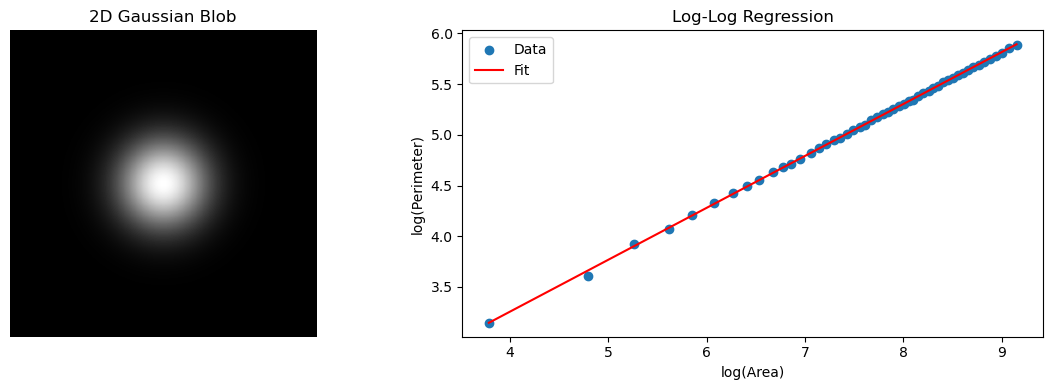

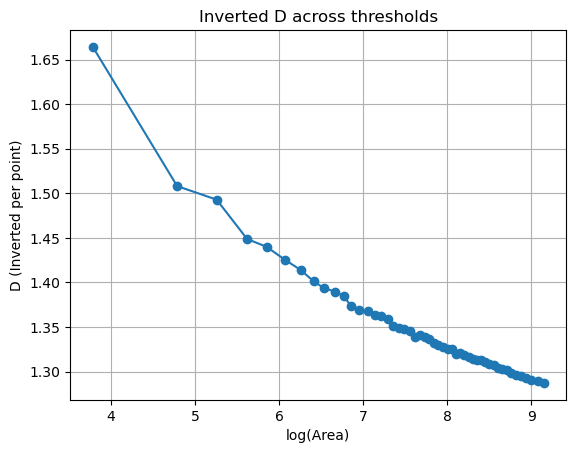

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure, filters

# Generate a 2D Gaussian
size = 256
x = np.linspace(-5, 5, size)
y = np.linspace(-5, 5, size)
X, Y = np.meshgrid(x, y)
sigma = 1.0
gaussian = np.exp(-(X**2 + Y**2) / (2 * sigma**2))

# Define thresholds
thresholds = np.linspace(0.1, 0.99, 50)

areas = []
perimeters = []

plt.figure(figsize=(12,4))

# For each threshold, find contours and compute area/perimeter
for i, t in enumerate(thresholds):
    mask = gaussian >= t

    # Label connected regions
    labeled = measure.label(mask)
    props = measure.regionprops(labeled)

    # Take the largest region (central blob)
    if props:
        largest = max(props, key=lambda r: r.area)
        areas.append(largest.area)
        perimeters.append(largest.perimeter)
    else:
        areas.append(np.nan)
        perimeters.append(np.nan)

# Convert to arrays and remove NaNs (in case thresholds too high)
areas = np.array(areas)
perimeters = np.array(perimeters)
valid = ~np.isnan(areas)
areas = areas[valid]
perimeters = perimeters[valid]

# Log-log regression
logA = np.log(areas)
logP = np.log(perimeters)

from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(logA, logP)
D_estimated_regression = 2 * slope

# Inverted D per point
D_inverted = 2 * logP / logA

# Print results
print("Estimated D from regression:", D_estimated_regression)
print("Mean D from inversion:", np.mean(D_inverted))
print("Std D from inversion:", np.std(D_inverted))

# Plotting
plt.subplot(1,2,1)
plt.imshow(gaussian, cmap='gray')
plt.title("2D Gaussian Blob")
plt.axis('off')

plt.subplot(1,2,2)
plt.scatter(logA, logP, label="Data")
plt.plot(logA, intercept + slope*logA, color='red', label="Fit")
plt.xlabel("log(Area)")
plt.ylabel("log(Perimeter)")
plt.legend()
plt.title("Log-Log Regression")

plt.tight_layout()
plt.show()

# Also show inverted D vs log(A)
plt.figure()
plt.plot(logA, D_inverted, 'o-')
plt.xlabel("log(Area)")
plt.ylabel("D (Inverted per point)")
plt.title("Inverted D across thresholds")
plt.grid(True)
plt.show()
